# Importing the Libraries

In [2]:
# Core libraries
import pickle
import warnings

# Numerical and data handling
import numpy as np
import pandas as pd
from scipy import stats

# Machine learning models
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError as KerasMAE

# Visualization
import matplotlib.pyplot as plt
import seaborn as sn

# Suppress warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Cleaning Data.

In [3]:
def wrangle(df):
    # Checking for Info.
    df.info()
    
    # checking for missing values.
    df.isnull().sum()
    df.dropna()
    
    # Compute Z-scores for all numeric columns
    z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))  # Apply Z-score only to numeric columns

    # Identify rows with Z-scores greater than 3 (or less than -3) for any column
    outliers_z = (z_scores > 3).any(axis=1)  # 'any' returns True if any column in the row is an outlier

    # Remove the outliers (keep only rows where outliers_z is False)
    df_cleaned = df[~outliers_z]


    # Optionally, save the cleaned dataset to a new CSV file
    df_cleaned.to_csv('cleaned_body_fat_data.csv', index=False)
    return df_cleaned

In [ ]:
df_cleaned = wrangle(pd.read_csv('bodyfat.csv'))

In [ ]:
# Compute the correlation matrix
corr_matrix = df.corr()
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Feature Selection

# Using ExtraTrees Regressor for Feature Selection

ExtraTrees Regressor
Purpose: The ExtraTrees Regressor is an ensemble learning method that uses multiple decision trees to provide feature importance. It is particularly effective at identifying non-linear relationships and interactions between features.
The feature importance from an ExtraTrees model reflects how much a feature contributes to the model's ability to make accurate predictions. Features with higher importance have a greater impact on the model's predictions.
When to Use ExtraTrees Regressor:
When you're working with complex, non-linear relationships between features and the target variable.
If you want to capture feature interactions that cannot be easily detected with linear models.
When you're using ensemble models or tree-based algorithms (e.g., Random Forest, Gradient Boosting, ExtraTrees) and you want to evaluate which features are most important for prediction.
When you need a model-agnostic feature selection method that works well with a wide range of machine learning algorithms.

In [5]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import ExtraTreesRegressor

In [6]:
data_cl = df_cleaned.copy()
y = data_cl['BodyFat']
X = data_cl.drop(['BodyFat'],axis=1)

In [7]:
data_cl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  242 non-null    float64
 1   BodyFat  242 non-null    float64
 2   Age      242 non-null    int64  
 3   Weight   242 non-null    float64
 4   Height   242 non-null    float64
 5   Neck     242 non-null    float64
 6   Chest    242 non-null    float64
 7   Abdomen  242 non-null    float64
 8   Hip      242 non-null    float64
 9   Thigh    242 non-null    float64
 10  Knee     242 non-null    float64
 11  Ankle    242 non-null    float64
 12  Biceps   242 non-null    float64
 13  Forearm  242 non-null    float64
 14  Wrist    242 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 30.2 KB


In [8]:
#After Cleaning the data 242 entries were found.

In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
er = ExtraTreesRegressor()
er.fit(X_train,y_train)

ExtraTreesRegressor()

In [10]:
#Output of feature importance
er.feature_importances_

array([0.68127962, 0.00191975, 0.0231181 , 0.0046542 , 0.00344663,
       0.05880685, 0.18983704, 0.01357273, 0.0077102 , 0.00535854,
       0.00166749, 0.00272625, 0.00253864, 0.00336395])

<Axes: >

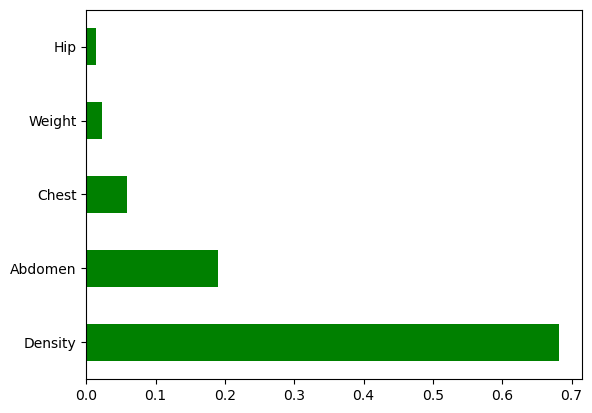

In [11]:
series = pd.Series(er.feature_importances_, index = X.columns)
series.nlargest(5).plot(kind='barh',color='green')

In [12]:
data_cl

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,1.0736,11.0,70,134.25,67.00,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5
248,1.0236,33.6,72,201.00,69.75,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1
249,1.0328,29.3,72,186.75,66.00,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0
250,1.0399,26.0,72,190.75,70.50,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8



1. DecisionTreeRegressor, RandomForestRegressor, and MLPRegressor
These models are all non-linear machine learning algorithms that can handle complex interactions and relationships between features. Here’s a breakdown of each:

DecisionTreeRegressor: Can model non-linear relationships by splitting the data based on feature thresholds.
RandomForestRegressor: An ensemble of decision trees that improves predictive power and generalization by aggregating the results of multiple decision trees.
MLPRegressor: A neural network that can model highly complex, non-linear relationships and interactions between features.
Since all these models handle non-linear relationships well, they are less sensitive to multicollinearity (compared to linear models). Therefore, the issue of multicollinearity (which VIF addresses) is less critical when using these models.

# Creating Seperate ML models.

# Creating the Hybrid models.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Hyperparameter tuning for Decision Tree Regressor
dt_param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', None],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],  # Corrected this line
    'splitter': ['best', 'random'],
    'max_leaf_nodes': [None, 10, 20],
    'min_impurity_decrease': [0.0, 0.01]
}
dt_grid_search = GridSearchCV(DecisionTreeRegressor(), dt_param_grid, cv=5, n_jobs=-1, verbose=1)
dt_grid_search.fit(X_train, y_train)
best_dt = dt_grid_search.best_estimator_

# Hyperparameter tuning for Random Forest Regressor
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False],
    'oob_score': [True, False],
    'warm_start': [True, False],
    'n_jobs': [-1]  # Use all available CPUs
}
rf_grid_search = GridSearchCV(RandomForestRegressor(), rf_param_grid, cv=5, n_jobs=-1, verbose=1)
rf_grid_search.fit(X_train, y_train)
best_rf = rf_grid_search.best_estimator_

# Hyperparameter tuning for MLP Regressor
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (100, 100)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [1000],
    'batch_size': ['auto', 16, 32],
    'early_stopping': [True, False],
    'tol': [1e-4, 1e-5],
    'momentum': [0.9, 0.95],
    'nesterovs_momentum': [True, False]
}
mlp_grid_search = GridSearchCV(MLPRegressor(max_iter=1000), mlp_param_grid, cv=5, n_jobs=-1, verbose=1)
mlp_grid_search.fit(X_train, y_train)
best_mlp = mlp_grid_search.best_estimator_

# Train models with the best parameters
best_dt.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_mlp.fit(X_train, y_train)

# Make predictions
dt_predictions = best_dt.predict(X_test)
rf_predictions = best_rf.predict(X_test)
mlp_predictions = best_mlp.predict(X_test)

# Combine predictions using simple averaging
hybrid_predictions = (dt_predictions + rf_predictions + mlp_predictions) / 3

# Evaluate the model
mae = mean_absolute_error(y_test, hybrid_predictions)
rmse = np.sqrt(mean_squared_error(y_test, hybrid_predictions))

print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

# Save the hybrid model using pickle
hybrid_model = {
    'decision_tree': best_dt,
    'random_forest': best_rf,
    'mlp': best_mlp
}

with open('hybrid_model.pkl', 'wb') as file:
    pickle.dump(hybrid_model, file)

print("Hybrid model saved as hybrid_model.pkl")

# Plot decision tree
plt.figure(figsize=(20,10))
plot_tree(best_dt, feature_names=X.columns, filled=True, rounded=True)
plt.title("Decision Tree for Body Fat Prediction")
plt.show()


Fitting 5 folds for each of 3888 candidates, totalling 19440 fits
Fitting 5 folds for each of 1944 candidates, totalling 9720 fits
Fitting 5 folds for each of 6144 candidates, totalling 30720 fits


The image shows a decision tree model created to predict body fat percentage. A decision tree is a flowchart-like structure where each internal node represents a "test" on an attribute (like chest, hip, weight, etc.), each branch represents the outcome of the test, and each leaf node represents a prediction outcome (in this case, a specific range of body fat).

Here's a simplified breakdown of how it works:

1. Top Node (Root): The model starts with a question at the top (root node). This question divides the data based on an attribute, aiming to create two groups that are as different as possible regarding body fat.


2. Branches and Splits: From the root, each question (or split) is based on different attributes and conditions. Each branch leads to another node where another question is asked. This process continues down the tree, creating more specific groups based on combinations of conditions.


3. Leaf Nodes (End Points): At the bottom of the tree, the branches end at leaf nodes, where the model makes a final prediction. Each leaf node represents a predicted range or value for body fat percentage, based on the path taken through the tree.



The deeper the tree and the more nodes it has, the more complex the model is. This particular decision tree is quite large, indicating that it's capturing many conditions and variations to improve accuracy in predicting body fat percentage.

In [ ]:
!pip install numpy

In [ ]:
import sklearn
print(sklearn.__version__)